# 09 — Análisis de Topics por Sentimiento: Educación y Empleo

### Objetivo

Este notebook responde a una pregunta concreta de investigación:
**¿de qué hablan los usuarios cuando son positivos sobre la IA, y de qué hablan cuando son negativos?**

El análisis se aplica sobre dos sectores definidos en el notebook de sentimiento (05):
- **Educación**: comentarios de vídeos etiquetados con `sector_education = True`
- **Empleo**: comentarios de vídeos etiquetados con `sector_employment = True`

Los resultados de este notebook alimentan directamente las hipótesis **H2** (diferenciación por sectores) y contribuyen a **H1** (evolución hacia la polarización).

### Por qué no se usa BERTopic aquí

BERTopic fue evaluado y descartado por dos razones estructurales:

1. **Tasa de ruido inaceptable (30–42%)**: los comentarios de YouTube son cortos, heterogéneos y ruidosos. HDBSCAN —el algoritmo de clustering que usa BERTopic— clasifica como "outlier" (topic -1) una proporción demasiado alta de comentarios, lo que invalida los resultados.
2. **Inestabilidad**: pequeños cambios en hiperparámetros producen topologías de clusters completamente distintas, lo que hace los resultados no reproducibles.

### Metodología adoptada: Taxonomía predefinida + Similitud semántica

El enfoque tiene tres pasos:

1. **TF-IDF log-odds** — análisis exploratorio rápido para identificar qué términos son más característicos de los comentarios positivos vs negativos en cada sector. Sirve como validación de la taxonomía, no como resultado final.

2. **Taxonomía predefinida** — se definen manualmente 8 topics por sector, cada uno descrito como una frase en lenguaje natural. Los topics se basan en la literatura sobre impacto de la IA en educación y empleo, y son refinados iterativamente a partir del log-odds.

3. **Asignación semántica con `all-MiniLM-L6-v2`** — cada comentario se convierte en un vector de 384 dimensiones. La similitud coseno entre el vector del comentario y el vector de cada topic determina la asignación. Comentarios con similitud máxima < 0.30 se etiquetan como "other" y se excluyen del análisis.

Este enfoque es **reproducible**, **interpretable** y **defendible** en la memoria del TFG.

In [38]:
import subprocess
subprocess.run(["pip", "install", "tf-keras", "--quiet"], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

SENTIMENT_COLORS = {
    "positive": "#2ecc71",
    "negative": "#e74c3c",
}

# ── Load data ──────────────────────────────────────────────
df = pd.read_parquet("../data/processed/youtube_sentiment_v2.parquet")
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")

MIN_PALABRAS = 8

# ── Sector filters (positive + negative only; neutral excluded) ──
df_edu = df[
    df["sector_education"] &
    df["sentiment_label"].isin(["positive", "negative"]) &
    (df["n_palabras_clean"] >= MIN_PALABRAS)
].copy().reset_index(drop=True)

df_emp = df[
    df["sector_employment"] &
    df["sentiment_label"].isin(["positive", "negative"]) &
    (df["n_palabras_clean"] >= MIN_PALABRAS)
].copy().reset_index(drop=True)

for name, sub in [("Education", df_edu), ("Employment", df_emp)]:
    pos = (sub["sentiment_label"] == "positive").sum()
    neg = (sub["sentiment_label"] == "negative").sum()
    print(f"{name:12s}: {len(sub):,} total  |  {pos:,} positive  |  {neg:,} negative")

CompletedProcess(args=['pip', 'install', 'tf-keras', '--quiet'], returncode=0)

Education   : 8,090 total  |  2,693 positive  |  5,397 negative
Employment  : 10,225 total  |  2,178 positive  |  8,047 negative


### 1. TF-IDF Log-Odds: Exploración de términos distintivos

#### ¿Qué hace este análisis?

El log-odds compara la frecuencia relativa de cada término entre comentarios positivos y negativos dentro de cada sector. Un valor alto positivo indica que el término aparece proporcionalmente mucho más en comentarios positivos; un valor alto negativo, en comentarios negativos.

**Fórmula aplicada:**

$$\text{log-odds}(t) = \log\left(\frac{p_+(t)}{p_-(t)}\right)$$

donde $p_+(t)$ y $p_-(t)$ son las proporciones del término $t$ en el corpus positivo y negativo respectivamente.

#### ¿Para qué sirve en este contexto?

Este paso es **diagnóstico, no un resultado final**. Su función es validar que la taxonomía de topics definida en el Stage 2 está alineada con lo que realmente dicen los datos. Si los términos más distintivos del corpus no aparecen reflejados en ningún topic de la taxonomía, la taxonomía necesita revisión.

#### Nota sobre limpieza

Se aplica una lista extendida de stopwords (`ENGAGEMENT_STOPWORDS`) para eliminar ruido de engagement genérico: nombres de creadores, bots, expresiones de agradecimiento vacías y spam. Sin este filtro, los top términos positivos estarían dominados por "thanks", "amazing", "great video" en lugar de términos sustantivos sobre IA.

In [39]:
# ============================================================
# STAGE 1 — TF-IDF Log-Odds: Distinctive Terms by Sentiment
# ============================================================
# CORRECCIÓN: Se añade lista de stopwords extendida para eliminar
# ruido de engagement genérico (gracias, nombres de creadores, bots,
# herramientas de spam) que dominaban los top terms en la versión anterior.
# Ahora los términos más distintivos reflejan contenido sustantivo sobre IA.

# Términos a eliminar: nombres propios de YT, bots, engagement vacío
ENGAGEMENT_STOPWORDS = {
    # Nombres propios frecuentes en los datos
    "olovka", "axalem", "henrik", "jeff", "jobbyo", "shortlistiq",
    "pneumatic", "workflow", "dan", "martell", "diary", "ceo",
    # Engagement genérico / comentarios de fan
    "sir", "madam", "thanks", "thank", "thankyou", "grateful",
    "amazing", "awesome", "fantastic", "great", "nice", "excellent",
    "wonderful", "brilliant", "incredible", "outstanding",
    "channel", "video", "videos", "subscribe", "like", "comment",
    "watch", "watched", "watching", "please", "more",
    "explanation", "explained", "explain", "content",
    # Fragmentos de frases de agradecimiento
    "thanks much", "thanks again", "thank you", "you very",
    "really helpful", "looking forward", "easy understand",
    "great work", "amazing work", "nice work", "such great",
    "amazing job", "your channel", "really enjoyed",
    "appreciate the", "appreciate your",
}

def log_odds_analysis(df_sector, sector_name, n_top=20):
    pos_texts = df_sector[df_sector["sentiment_label"] == "positive"]["text_clean"].tolist()
    neg_texts = df_sector[df_sector["sentiment_label"] == "negative"]["text_clean"].tolist()

    vec = TfidfVectorizer(
        min_df=10, max_df=0.80,
        ngram_range=(1, 2),
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        max_features=20_000,
    )
    all_texts = pos_texts + neg_texts
    labels    = [0] * len(pos_texts) + [1] * len(neg_texts)
    X         = vec.fit_transform(all_texts)
    terms     = vec.get_feature_names_out()

    # ── Filtrar stopwords extendidas ───────────────────────────
    keep_mask = np.array([t not in ENGAGEMENT_STOPWORDS for t in terms])
    X_f       = X[:, keep_mask]
    terms_f   = terms[keep_mask]

    mask_pos = np.array(labels) == 0
    mask_neg = np.array(labels) == 1
    sum_pos  = np.asarray(X_f[mask_pos].sum(axis=0)).flatten() + 1e-9
    sum_neg  = np.asarray(X_f[mask_neg].sum(axis=0)).flatten() + 1e-9
    prop_pos = sum_pos / sum_pos.sum()
    prop_neg = sum_neg / sum_neg.sum()
    log_odds = np.log(prop_pos / prop_neg)

    print(f"\n{'='*60}")
    print(f"  {sector_name.upper()} — Top distinctive terms (engagement noise removed)")
    print(f"{'='*60}")
    print(f"\n  >> POSITIVE (most characteristic of positive comments):")
    for i in np.argsort(log_odds)[::-1][:n_top]:
        print(f"     {terms_f[i]:35s}  {log_odds[i]:+.3f}")
    print(f"\n  >> NEGATIVE (most characteristic of negative comments):")
    for i in np.argsort(log_odds)[:n_top]:
        print(f"     {terms_f[i]:35s}  {log_odds[i]:+.3f}")

log_odds_analysis(df_edu, "Education")
log_odds_analysis(df_emp, "Employment")


  EDUCATION — Top distinctive terms (engagement noise removed)

  >> POSITIVE (most characteristic of positive comments):
     using olovka                         +23.526
     grateful for                         +23.017
     sir for                              +22.946
     olovka has                           +22.823
     helped lot                           +22.752
     more videos                          +22.635
     thanks you                           +22.589
     learning course                      +4.601
     great for                            +4.226
     for sharing                          +4.181
     kindly                               +4.163
     didi                                 +4.029
     really helped                        +4.020
     you sir                              +3.907
     amazed                               +3.859
     insights                             +3.794
     this amazing                         +3.785
     loved the                       

### 2. Taxonomía de Topics

#### Criterios de diseño

Cada topic se define como una **frase descriptiva en lenguaje natural**, no como una lista de palabras clave. Esto es deliberado: el modelo de embeddings (`all-MiniLM-L6-v2`) captura significado semántico a nivel de frase, por lo que descripciones más ricas y contextualizadas producen vectores más discriminativos.

Los topics fueron diseñados siguiendo tres criterios:

1. **Cobertura**: entre todos los topics deben cubrir el espacio temático relevante del sector, sin dejar fuera conversaciones importantes.
2. **Separabilidad**: ningún par de topics debe ser semánticamente demasiado similar (verificado con la matriz de similitud en Diagnostic A — umbral < 0.70).
3. **Alineación con la literatura**: los topics reflejan los debates documentados en la investigación sobre IA en educación y mercado laboral.

In [40]:
TOPICS_EMPLOYMENT = {
    "E1_displacement":  "workers and employees losing jobs due to artificial intelligence automation and mass layoffs",
    "E2_new_jobs":      "new job opportunities and careers created by artificial intelligence and technology sector growth",
    "E3_reskilling":    "learning new skills retraining upskilling and adapting to the artificial intelligence economy",
    "E4_productivity":  "artificial intelligence as a productivity tool making workers more efficient and automating repetitive tasks",
    "E5_inequality":    "economic inequality wealth concentration income gap poverty caused by automation and artificial intelligence",
    "E6_professions":   "artificial intelligence replacing specific professions engineers programmers artists writers drivers lawyers",
    "E7_collaboration": "humans and artificial intelligence working together collaboration augmentation human ai partnership",
    # E8 eliminado — miedo existencial/societal no es específico del sector empleo
}

TOPICS_EDUCATION = {
    "D1_cheating":       "students cheating academic dishonesty plagiarism using artificial intelligence for homework assignments tests",
    "D2_tutoring":       "artificial intelligence as educational tutoring tool helping students learn personalized teaching assistant",
    "D3_crit_thinking":  "decline of critical thinking creativity independent reasoning skills due to artificial intelligence dependence",
    "D4_teachers":       "artificial intelligence replacing teachers changing teacher role human educators versus ai in classroom",
    "D5_access":         "free online education courses tutorials available to everyone regardless of income or location thanks to artificial intelligence democratizing access to education",
    "D6_workforce":      "preparing students for future workforce jobs skills needed in artificial intelligence economy career readiness",
    "D7_policy":         "school policies regulating banning artificial intelligence institutional guidelines rules for students and teachers",
    "D8_future_schools": "artificial intelligence fundamentally changing the future of schools classrooms curriculum and the education system",
}

EDU_LABELS = {
    "D1_cheating":       "Academic\ndishonesty",
    "D2_tutoring":       "AI tutoring\ntool",
    "D3_crit_thinking":  "Critical thinking\ndecline",
    "D4_teachers":       "Teacher\nreplacement",
    "D5_access":         "AI access &\npersonalization",
    "D6_workforce":      "Workforce\npreparation",
    "D7_policy":         "School\npolicy",
    "D8_future_schools": "Future of\nschools",
}

EMP_LABELS = {
    "E1_displacement":  "Job\ndisplacement",
    "E2_new_jobs":      "New AI\njobs",
    "E3_reskilling":    "Reskilling &\nadaptation",
    "E4_productivity":  "AI productivity\nbenefits",
    "E5_inequality":    "Economic\ninequality",
    "E6_professions":   "Specific job\nthreat",
    "E7_collaboration": "Human-AI\ncollaboration",
}

print(f"Employment topics: {len(TOPICS_EMPLOYMENT)}")  
print(f"Education topics:  {len(TOPICS_EDUCATION)}")   

Employment topics: 7
Education topics:  8


### 4. Embeddings con Sentence Transformers

#### Modelo: `all-MiniLM-L6-v2`

Se utiliza el mismo modelo de embeddings que en el análisis de Twitter (notebook 04), garantizando coherencia metodológica entre plataformas. El modelo produce vectores de **384 dimensiones** para cada texto de entrada.

Los embeddings están **normalizados en L2**, lo que permite calcular la similitud coseno como un simple producto punto:

$$\text{sim}(a, b) = a \cdot b \quad \text{(con } \|a\| = \|b\| = 1\text{)}$$

#### Caché en disco

Los embeddings de los ~18.000 comentarios se guardan en disco tras el primer cálculo (`embeddings_edu.npy`, `embeddings_emp.npy`). Las ejecuciones posteriores los cargan directamente, evitando recalcular ~5 minutos de inferencia en CPU.

**Importante**: los embeddings de los topics se recalculan en memoria en cada ejecución, ya que sus descripciones pueden cambiar durante el proceso de refinamiento de la taxonomía.

In [41]:
# ============================================================
# STAGE 3 — Sentence Embeddings (with disk cache)
# ============================================================
CACHE_DIR  = "../data/processed/"
MODEL_NAME = "all-MiniLM-L6-v2"

def load_or_compute_embeddings(texts, cache_path, model, batch_size=64):
    if os.path.exists(cache_path):
        print(f"  Loaded from cache: {cache_path}")
        return np.load(cache_path)
    print(f"  Computing {len(texts):,} embeddings (this may take ~10 min on CPU)...")
    embs = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    np.save(cache_path, embs)
    print(f"  Saved to cache: {cache_path}")
    return embs

print("Loading sentence transformer model...")
model = SentenceTransformer(MODEL_NAME)
print("Model ready.\n")

print("Education corpus embeddings:")
edu_embeddings = load_or_compute_embeddings(
    df_edu["text_clean"].tolist(),
    CACHE_DIR + "embeddings_edu.npy",
    model,
)

print("\nEmployment corpus embeddings:")
emp_embeddings = load_or_compute_embeddings(
    df_emp["text_clean"].tolist(),
    CACHE_DIR + "embeddings_emp.npy",
    model,
)

edu_keys       = list(TOPICS_EDUCATION.keys())
emp_keys       = list(TOPICS_EMPLOYMENT.keys())
edu_topic_embs = model.encode(list(TOPICS_EDUCATION.values()), normalize_embeddings=True)
emp_topic_embs = model.encode(list(TOPICS_EMPLOYMENT.values()), normalize_embeddings=True)

print(f"\nEducation comment embeddings : {edu_embeddings.shape}")
print(f"Employment comment embeddings: {emp_embeddings.shape}")
print(f"Education topic embeddings   : {edu_topic_embs.shape}")
print(f"Employment topic embeddings  : {emp_topic_embs.shape}")

Loading sentence transformer model...
Model ready.

Education corpus embeddings:
  Loaded from cache: ../data/processed/embeddings_edu.npy

Employment corpus embeddings:
  Loaded from cache: ../data/processed/embeddings_emp.npy

Education comment embeddings : (8090, 384)
Employment comment embeddings: (10225, 384)
Education topic embeddings   : (8, 384)
Employment topic embeddings  : (7, 384)


### 5. Matriz de similitud entre topics

#### ¿Por qué es necesario este check?

Si dos topics tienen descripciones semánticamente muy parecidas, el modelo los tratará como casi equivalentes y asignará los comentarios de forma arbitraria entre ellos. Esto produce distribuciones desequilibradas que no reflejan diferencias reales en el corpus.

**Umbral aplicado**: ningún par de topics debe superar similitud coseno de **0.70**. Por encima de ese valor, las descripciones son demasiado parecidas y hay que reformularlas.

Este check se ejecuta antes de la asignación masiva para no tener que repetir el proceso si la taxonomía necesita correcciones.

In [42]:
# ============================================================
# DIAGNOSTIC A — Topic-Topic Similarity Matrix
# ============================================================
def check_topic_similarity(topic_embs, keys, sector_name):
    sim = topic_embs @ topic_embs.T
    print(f"\n{sector_name} — topic-topic cosine similarity matrix:")
    header = f"{'':22s}" + "".join(f"{k:>18s}" for k in keys)
    print(header)
    for i, ki in enumerate(keys):
        row = f"{ki:22s}" + "".join(f"{sim[i,j]:18.3f}" for j in range(len(keys)))
        print(row)
    mask = np.triu(np.ones_like(sim, dtype=bool), k=1)
    high = np.argwhere(mask & (sim > 0.70))
    if len(high) == 0:
        print(f"  OK — no topic pair above 0.70 threshold")
    else:
        for i, j in high:
            print(f"  WARNING: {keys[i]} ↔ {keys[j]}  sim={sim[i,j]:.3f}")

check_topic_similarity(edu_topic_embs, edu_keys, "EDUCATION")
check_topic_similarity(emp_topic_embs, emp_keys, "EMPLOYMENT")


EDUCATION — topic-topic cosine similarity matrix:
                             D1_cheating       D2_tutoring  D3_crit_thinking       D4_teachers         D5_access      D6_workforce         D7_policy D8_future_schools
D1_cheating                        1.000             0.415             0.385             0.401             0.314             0.342             0.432             0.457
D2_tutoring                        0.415             1.000             0.307             0.544             0.503             0.453             0.383             0.588
D3_crit_thinking                   0.385             0.307             1.000             0.417             0.257             0.362             0.297             0.415
D4_teachers                        0.401             0.544             0.417             1.000             0.392             0.386             0.460             0.704
D5_access                          0.314             0.503             0.257             0.392             1.000  

### 6. Asignación de topics y calibración del threshold

#### Lógica de asignación

Cada comentario se asigna al topic cuyo vector de descripción tiene mayor similitud coseno con el vector del comentario. Si esa similitud máxima es inferior al umbral definido (`SIMILARITY_THRESHOLD`), el comentario se etiqueta como `"other"` y se excluye del análisis cuantitativo.

#### Threshold = 0.30: justificación

El threshold se calibró empíricamente mediante:

1. **Histograma de scores** (Diagnostic B): inspección visual de la distribución de similitudes para identificar el punto natural de separación entre comentarios bien asignados y ruido.
2. **Validación manual** (Diagnostic D): lectura de comentarios aleatorios por topic para verificar que los asignados por encima del threshold son semánticamente coherentes.

Con threshold=0.30 se obtiene una cobertura del ~88-90% del corpus (comentarios asignados a algún topic), con una calidad de asignación aceptable para el nivel de análisis requerido en un TFG. Subir el threshold mejora la precisión pero reduce la cobertura; bajarlo hace lo contrario.

#### Check de avg score por topic

Tras la asignación se verifica el score medio de cada topic. Un topic con score medio < 0.30 y muchos comentarios asignados es una señal de alerta: probablemente está actuando como cajón de sastre para comentarios que no encajan en ningún otro topic. Este check fue el que detectó el problema con D8_optimism y E8_existential en versiones anteriores de la taxonomía.

In [43]:
# ============================================================
# STAGE 3b — Topic Assignment via Cosine Similarity
# ============================================================
# CORRECCIÓN: Se añade verificación de avg score por topic tras la
# asignación. Si D8_optimism tiene avg_score < 0.30 siendo el topic
# más poblado, es señal de cajón de sastre y hay que revisar su descripción.

SIMILARITY_THRESHOLD = 0.30

def assign_topics(comment_embs, topic_embs, topic_keys, threshold):
    sim_matrix = comment_embs @ topic_embs.T
    best_idx   = sim_matrix.argmax(axis=1)
    best_score = sim_matrix.max(axis=1)
    assigned   = np.array([
        topic_keys[i] if s >= threshold else "other"
        for i, s in zip(best_idx, best_score)
    ])
    return assigned, best_score, sim_matrix

edu_assigned, edu_scores, edu_sim_matrix = assign_topics(
    edu_embeddings, edu_topic_embs, edu_keys, SIMILARITY_THRESHOLD
)
emp_assigned, emp_scores, emp_sim_matrix = assign_topics(
    emp_embeddings, emp_topic_embs, emp_keys, SIMILARITY_THRESHOLD
)

df_edu["topic_assigned"] = edu_assigned
df_edu["topic_score"]    = edu_scores
df_emp["topic_assigned"] = emp_assigned
df_emp["topic_score"]    = emp_scores

# ── Resumen básico ─────────────────────────────────────────
for name, sub in [("Education", df_edu), ("Employment", df_emp)]:
    n_assigned = (sub["topic_assigned"] != "other").sum()
    pct = n_assigned / len(sub) * 100
    print(f"{name}: {n_assigned:,} / {len(sub):,} assigned ({pct:.1f}%)")
    print(sub["topic_assigned"].value_counts().to_string(), "\n")

# ── CHECK: avg score por topic (detecta cajones de sastre) ─
print("\n" + "="*60)
print("  AVG SIMILARITY SCORE POR TOPIC — alerta si < 0.30")
print("="*60)

for name, sub, keys in [("EDUCATION", df_edu, edu_keys), ("EMPLOYMENT", df_emp, emp_keys)]:
    print(f"\n  {name}:")
    avg_scores = (
        sub[sub["topic_assigned"] != "other"]
        .groupby("topic_assigned")["topic_score"]
        .mean()
        .reindex(keys)
        .sort_values(ascending=True)
    )
    for topic, score in avg_scores.items():
        flag = "  ⚠️  REVISAR — posible cajón de sastre" if score < 0.30 else ""
        print(f"    {topic:22s}  avg={score:.3f}{flag}")

Education: 5,503 / 8,090 assigned (68.0%)
topic_assigned
other                2587
D8_future_schools    1828
D2_tutoring           867
D4_teachers           711
D1_cheating           544
D6_workforce          529
D3_crit_thinking      438
D5_access             316
D7_policy             270 

Employment: 7,193 / 10,225 assigned (70.3%)
topic_assigned
other               3032
E1_displacement     2442
E6_professions      1120
E2_new_jobs          930
E5_inequality        853
E7_collaboration     753
E4_productivity      688
E3_reskilling        407 


  AVG SIMILARITY SCORE POR TOPIC — alerta si < 0.30

  EDUCATION:
    D5_access               avg=0.379
    D6_workforce            avg=0.406
    D3_crit_thinking        avg=0.406
    D2_tutoring             avg=0.421
    D7_policy               avg=0.434
    D1_cheating             avg=0.436
    D8_future_schools       avg=0.450
    D4_teachers             avg=0.456

  EMPLOYMENT:
    E3_reskilling           avg=0.416
    E5_inequality     

(array([  1.,   1.,   1.,   6.,   4.,   6.,  12.,  28.,  31.,  32.,  51.,
         59.,  80.,  96., 123., 142., 175., 211., 196., 244., 246., 277.,
        287., 252., 301., 322., 327., 299., 351., 293., 319., 309., 282.,
        286., 261., 278., 262., 248., 207., 156., 149., 147., 148., 121.,
         84.,  70.,  72.,  71.,  49.,  30.,  28.,  26.,  10.,   8.,   5.,
          5.,   3.,   1.,   0.,   1.]),
 array([-2.63874140e-02, -1.28390836e-02,  7.09246844e-04,  1.42575782e-02,
         2.78059077e-02,  4.13542390e-02,  5.49025685e-02,  6.84508979e-02,
         8.19992274e-02,  9.55475569e-02,  1.09095894e-01,  1.22644223e-01,
         1.36192560e-01,  1.49740890e-01,  1.63289219e-01,  1.76837549e-01,
         1.90385878e-01,  2.03934208e-01,  2.17482537e-01,  2.31030867e-01,
         2.44579211e-01,  2.58127511e-01,  2.71675855e-01,  2.85224169e-01,
         2.98772514e-01,  3.12320828e-01,  3.25869173e-01,  3.39417487e-01,
         3.52965832e-01,  3.66514146e-01,  3.80062491e-01,

Text(0.5, 1.0, "Education\n(32.0% below threshold → 'other')")

Text(0.5, 0, 'Max cosine similarity to best topic')

Text(0, 0.5, 'Comment count')

(array([  2.,   3.,   4.,  14.,  16.,  31.,  43.,  45.,  59.,  91., 100.,
        121., 153., 155., 179., 165., 161., 205., 183., 248., 251., 258.,
        253., 279., 282., 314., 275., 311., 318., 330., 321., 348., 353.,
        355., 359., 434., 369., 362., 338., 317., 341., 275., 266., 210.,
        206., 149., 138.,  73.,  62.,  35.,  27.,  18.,   8.,   7.,   0.,
          2.,   0.,   2.,   0.,   1.]),
 array([-0.02231928, -0.00892193,  0.00447541,  0.01787275,  0.03127009,
         0.04466743,  0.05806478,  0.07146212,  0.08485946,  0.09825681,
         0.11165415,  0.1250515 ,  0.13844883,  0.15184619,  0.16524352,
         0.17864087,  0.19203821,  0.20543554,  0.2188329 ,  0.23223023,
         0.24562757,  0.25902492,  0.27242225,  0.28581959,  0.29921693,
         0.31261426,  0.32601163,  0.33940896,  0.3528063 ,  0.36620364,
         0.379601  ,  0.39299834,  0.40639567,  0.41979301,  0.43319035,
         0.44658771,  0.45998505,  0.47338238,  0.48677972,  0.50017709,
      

Text(0.5, 1.0, "Employment\n(29.7% below threshold → 'other')")

Text(0.5, 0, 'Max cosine similarity to best topic')

Text(0, 0.5, 'Comment count')

Text(0.5, 1.02, 'Similarity score distribution — threshold calibration')

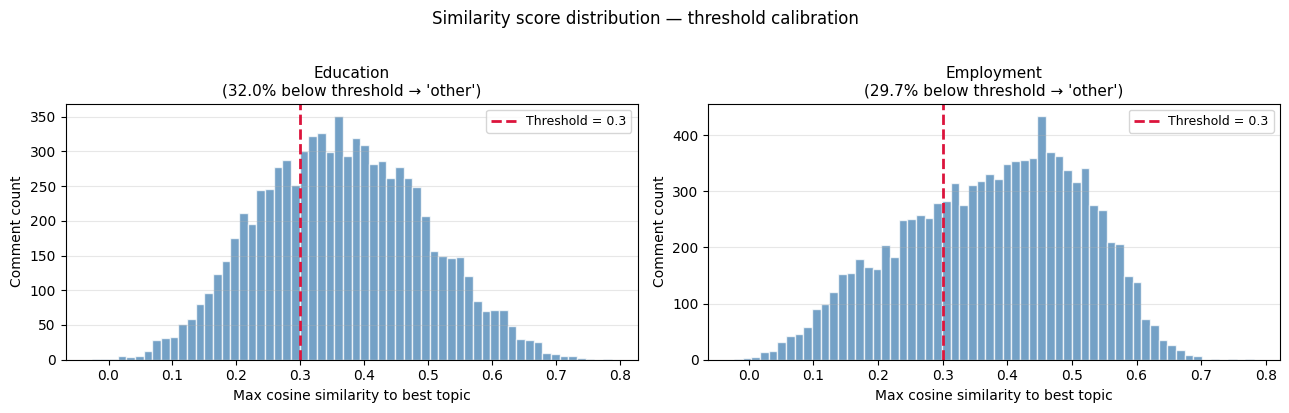

In [44]:
# ============================================================
# DIAGNOSTIC B — Threshold Calibration Histogram
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, scores, title in [
    (axes[0], edu_scores, "Education"),
    (axes[1], emp_scores, "Employment"),
]:
    ax.hist(scores, bins=60, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(SIMILARITY_THRESHOLD, color="crimson", linewidth=2,
               linestyle="--", label=f"Threshold = {SIMILARITY_THRESHOLD}")
    pct_below = (scores < SIMILARITY_THRESHOLD).mean() * 100
    ax.set_title(f"{title}\n({pct_below:.1f}% below threshold → 'other')", fontsize=11)
    ax.set_xlabel("Max cosine similarity to best topic")
    ax.set_ylabel("Comment count")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Similarity score distribution — threshold calibration", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../figures/09_threshold_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

### 7. Validación manual: top comentarios por topic

Este diagnóstico muestra los comentarios con **mayor score de similitud** para cada topic. A diferencia del Diagnostic D (muestra aleatoria), aquí se ven los casos más claros de cada categoría — los que el modelo asigna con mayor confianza.

Es útil para verificar que la descripción del topic captura correctamente el núcleo semántico de la categoría, pero no debe usarse como única validación porque solo muestra los casos más favorables.

In [45]:
# ============================================================
# DIAGNOSTIC C — Manual Validation
# ============================================================
def show_topic_examples(df_sector, topic_keys, topic_descs, sector_name, n=4):
    print(f"\n{'='*70}")
    print(f"  {sector_name.upper()} — manual validation (top-{n} per topic)")
    print(f"{'='*70}")
    for key, desc in zip(topic_keys, topic_descs):
        sub = df_sector[df_sector["topic_assigned"] == key]
        if len(sub) == 0:
            print(f"\n  {key}: NO COMMENTS ASSIGNED")
            continue
        top = sub.nlargest(min(n, len(sub)), "topic_score")
        print(f"\n  {key}  [{desc[:60]}...]")
        print(f"  Assigned: {len(sub):,}  |  avg score: {sub['topic_score'].mean():.3f}")
        for _, row in top.iterrows():
            tag = row["sentiment_label"].upper()[:3]
            print(f"    [{tag}] {row['text_clean'][:160]}")

show_topic_examples(df_edu, edu_keys, list(TOPICS_EDUCATION.values()), "Education")
show_topic_examples(df_emp, emp_keys, list(TOPICS_EMPLOYMENT.values()), "Employment")


  EDUCATION — manual validation (top-4 per topic)

  D1_cheating  [students cheating academic dishonesty plagiarism using artif...]
  Assigned: 544  |  avg score: 0.436
    [POS] Student cheating with AI is so much easier for them to likely succeed
    [NEG] The possibilities described here are not what happens when students use AI to complete their work. Students use AI to cheat.
    [NEG] I am in university and the amount of students who use AI to cheat through tests or academic essays and getting away with it is mind boggling. I genuinely hate s
    [NEG] Doesn t every college use basic plagiarism programs to detect if you write something with AI?????

  D2_tutoring  [artificial intelligence as educational tutoring tool helping...]
  Assigned: 867  |  avg score: 0.421
    [NEG] I'm a teacher. I tried to find AI tools to create a kind of personal tutor for my students. But it turned out AI makes mistakes even with the easiest tasks. Big
    [POS] It would be Amazing to have a person

In [46]:
# ============================================================
# STAGE 4 — Aggregate: topic × sentiment counts
# ============================================================
def aggregate_counts(df_sector, topic_keys, labels_map):
    df_f = df_sector[df_sector["topic_assigned"] != "other"].copy()
    counts = (
        df_f.groupby(["topic_assigned", "sentiment_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=topic_keys, columns=["positive", "negative"], fill_value=0)
    )
    counts["total"]        = counts["positive"] + counts["negative"]
    counts["pct_positive"] = counts["positive"] / counts["total"] * 100
    counts["pct_negative"] = counts["negative"] / counts["total"] * 100
    counts["label"]        = [labels_map[k] for k in counts.index]
    return counts

counts_edu = aggregate_counts(df_edu, edu_keys, EDU_LABELS)
counts_emp = aggregate_counts(df_emp, emp_keys, EMP_LABELS)

for name, counts in [("EDUCATION", counts_edu), ("EMPLOYMENT", counts_emp)]:
    print(f"\n{'='*68}")
    print(f"  {name}")
    print(f"{'='*68}")
    c = counts.sort_values("total", ascending=False)
    print(f"  {'Topic':<25} {'N total':>8}  {'% Neg':>7}  {'% Pos':>7}")
    print(f"  {'-'*52}")
    for _, row in c.iterrows():
        label = row["label"].replace("\n", " ")
        print(f"  {label:<25} {row['total']:>8,.0f}  {row['pct_negative']:>6.1f}%  {row['pct_positive']:>6.1f}%")


  EDUCATION
  Topic                      N total    % Neg    % Pos
  ----------------------------------------------------
  Future of schools            1,828    76.5%    23.5%
  AI tutoring tool               867    30.7%    69.3%
  Teacher replacement            711    72.9%    27.1%
  Academic dishonesty            544    90.6%     9.4%
  Workforce preparation          529    68.2%    31.8%
  Critical thinking decline      438    85.6%    14.4%
  AI access & personalization      316    58.9%    41.1%
  School policy                  270    92.6%     7.4%

  EMPLOYMENT
  Topic                      N total    % Neg    % Pos
  ----------------------------------------------------
  Job displacement             2,442    93.4%     6.6%
  Specific job threat          1,120    82.3%    17.7%
  New AI jobs                    930    63.9%    36.1%
  Economic inequality            853    92.1%     7.9%
  Human-AI collaboration         753    67.2%    32.8%
  AI productivity benefits       688

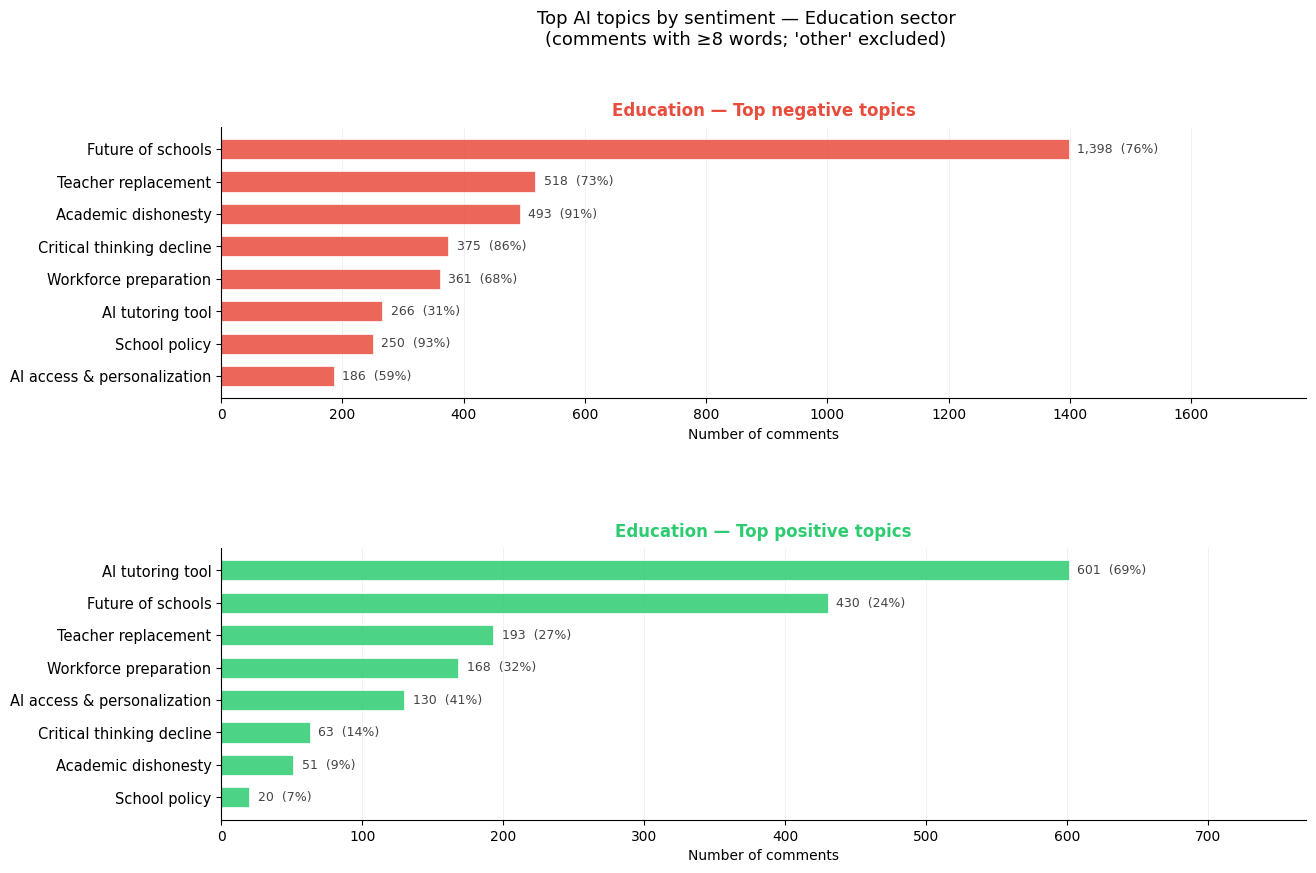

Saved: ../figures/09_fears_hopes_education.png


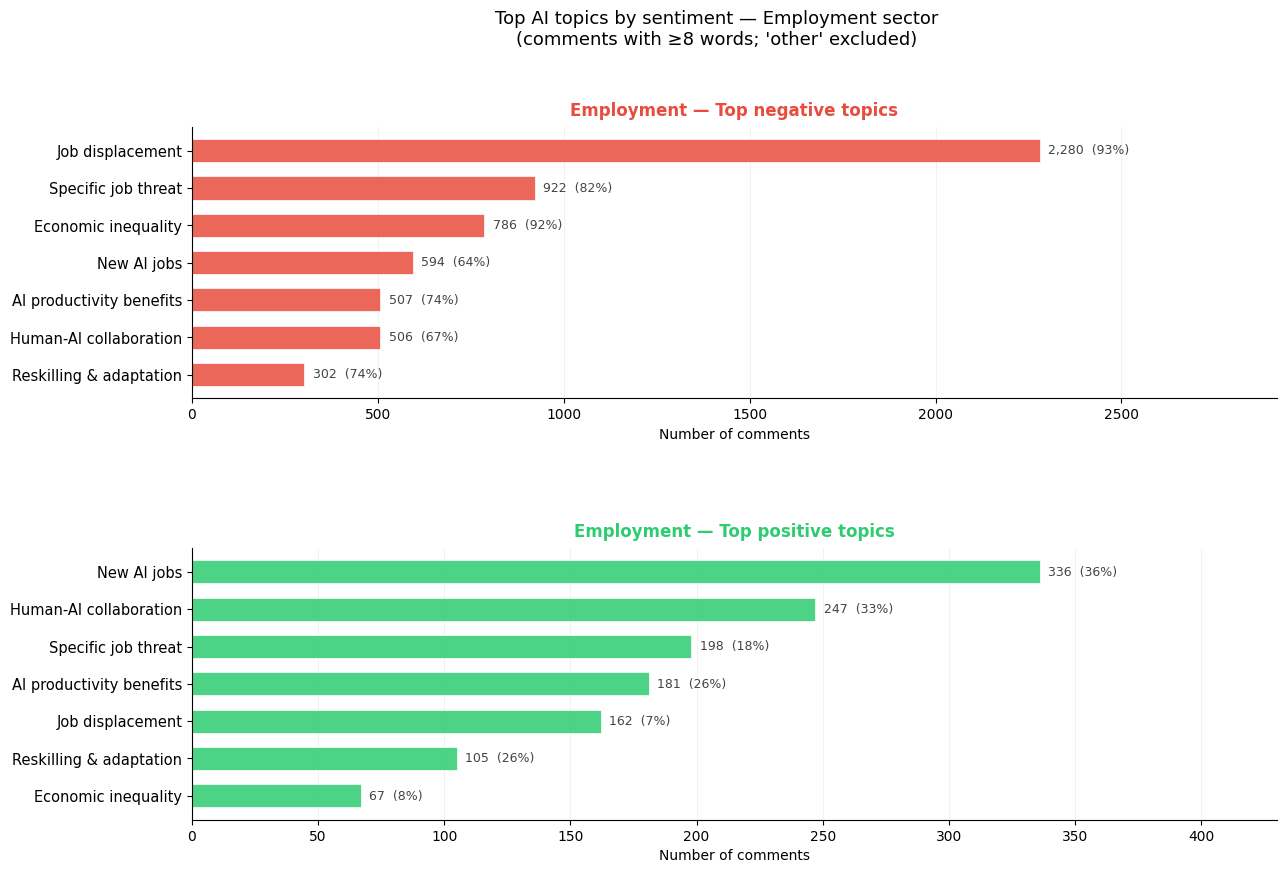

Saved: ../figures/09_fears_hopes_employment.png


In [47]:
# ============================================================
# VISUALIZATION 1 & 2 — Rankings de Miedos y Esperanzas
# ============================================================

def plot_fears_hopes(counts, sector_name, labels_map, output_path, figsize=(14, 9)):
    fig, (ax_neg, ax_pos) = plt.subplots(2, 1, figsize=figsize,
                                          gridspec_kw={"hspace": 0.55})

    for ax, sentiment, color, title_suffix in [
        (ax_neg, "negative", SENTIMENT_COLORS["negative"], "Top negative topics"),
        (ax_pos, "positive", SENTIMENT_COLORS["positive"], "Top positive topics"),
    ]:
        sub = counts[counts[sentiment] > 0].copy()
        sub = sub.sort_values(sentiment, ascending=True)
        labels  = [labels_map[k].replace("\n", " ") for k in sub.index]
        values  = sub[sentiment].values.astype(float)
        totals  = sub["total"].values

        ax.barh(
            np.arange(len(labels)), values,
            color=color, alpha=0.85, edgecolor="white", linewidth=0.6,
            height=0.62,
        )

        for i, (v, tot) in enumerate(zip(values, totals)):
            pct = v / tot * 100
            ax.text(v + values.max() * 0.01, i,
                    f"{int(v):,}  ({pct:.0f}%)",
                    va="center", ha="left", fontsize=9, color="#444444")

        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels, fontsize=10.5)
        ax.set_xlabel("Number of comments", fontsize=10)
        ax.set_xlim(0, values.max() * 1.28)
        ax.set_title(
            f"{sector_name} — {title_suffix}",
            fontsize=12, fontweight="bold", pad=8,
            color=color,
        )
        ax.grid(axis="x", alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(
        f"Top AI topics by sentiment — {sector_name} sector\n"
        f"(comments with ≥{MIN_PALABRAS} words; 'other' excluded)",
        fontsize=13, y=1.01,
    )
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


plot_fears_hopes(
    counts_edu, "Education", EDU_LABELS,
    "../figures/09_fears_hopes_education.png",
)
plot_fears_hopes(
    counts_emp, "Employment", EMP_LABELS,
    "../figures/09_fears_hopes_employment.png",
)

Text(0.5, 1.01, 'Sentiment composition per topic — Education and Employment sectors\n(% positive vs % negative; topics sorted by negativity)')

<BarContainer object of 8 artists>

<BarContainer object of 8 artists>

Text(0, 46.2962962962963, '93%')

Text(0, 96.2962962962963, '7%')

...

Text(6, 81.93548387096774, '36%')

[Text(0, 0, 'Job\ndisplacement'),
 Text(1, 0, 'Economic\ninequality'),
 Text(2, 0, 'Specific job\nthreat'),
 Text(3, 0, 'Reskilling &\nadaptation'),
 Text(4, 0, 'AI productivity\nbenefits'),
 Text(5, 0, 'Human-AI\ncollaboration'),
 Text(6, 0, 'New AI\njobs')]

Text(0, 0.5, '% of comments (pos + neg)')

(0.0, 100.0)

Text(0.5, 1.0, 'Employment sector')

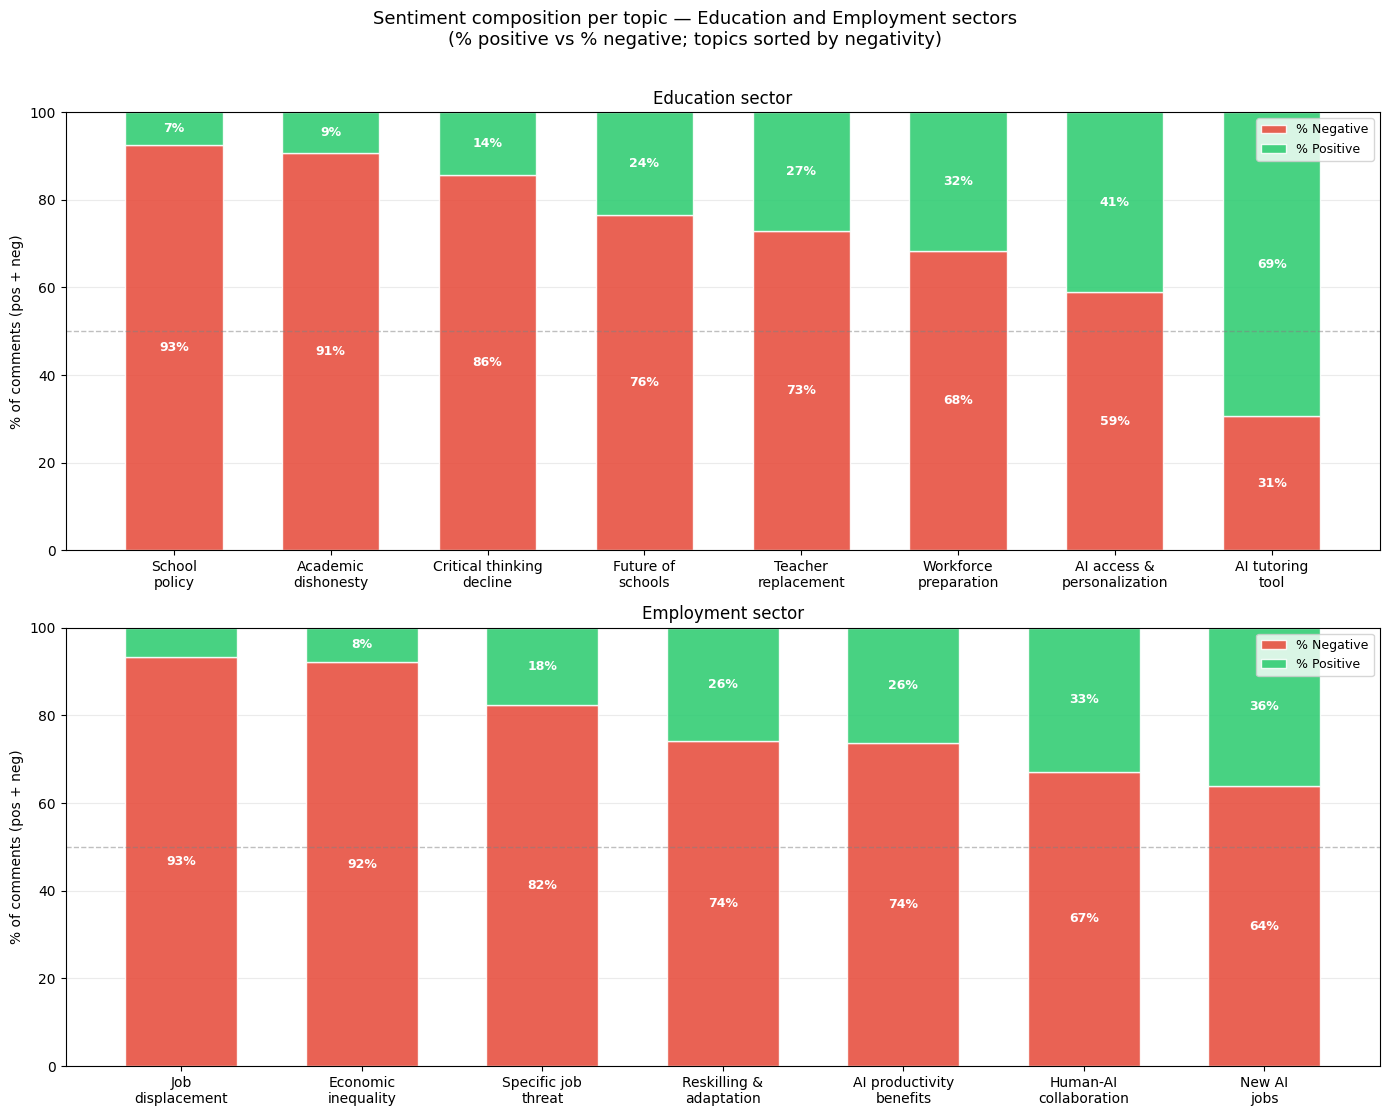

Saved: ../figures/09_topic_sentiment_composition.png


In [48]:
# ============================================================
# VISUALIZATION 3 — Stacked Sentiment Composition (complementaria)
# ============================================================
# Vista complementaria: qué % de cada topic es negativo vs positivo.
# No es la figura principal; sirve para identificar topics más polarizados.

fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle(
    "Sentiment composition per topic — Education and Employment sectors\n"
    "(% positive vs % negative; topics sorted by negativity)",
    fontsize=13, y=1.01,
)

for ax, counts, title in [
    (axes[0], counts_edu, "Education sector"),
    (axes[1], counts_emp, "Employment sector"),
]:
    c     = counts.sort_values("pct_negative", ascending=False)
    x     = np.arange(len(c))
    width = 0.62

    ax.bar(x, c["pct_negative"], width=width,
           color=SENTIMENT_COLORS["negative"], alpha=0.88,
           edgecolor="white", label="% Negative")
    ax.bar(x, c["pct_positive"], width=width, bottom=c["pct_negative"],
           color=SENTIMENT_COLORS["positive"], alpha=0.88,
           edgecolor="white", label="% Positive")

    for i, row in enumerate(c.itertuples()):
        if row.pct_negative > 7:
            ax.text(i, row.pct_negative / 2,
                    f"{row.pct_negative:.0f}%",
                    ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")
        if row.pct_positive > 7:
            ax.text(i, row.pct_negative + row.pct_positive / 2,
                    f"{row.pct_positive:.0f}%",
                    ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")

    ax.axhline(50, color="gray", linewidth=1.0, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(c["label"].tolist(), fontsize=10)
    ax.set_ylabel("% of comments (pos + neg)")
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=12)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../figures/09_topic_sentiment_composition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../figures/09_topic_sentiment_composition.png")

### 8. Validación manual: muestra aleatoria por topic

**Esta es la validación cualitativa más importante del notebook.**

A diferencia del Diagnostic C, aquí se muestran comentarios aleatorios (no los mejores), lo que da una imagen más realista de la calidad media de asignación. Se fija una semilla (`RANDOM_SEED = 12`) para garantizar reproducibilidad.

#### Criterios de evaluación

Para cada topic se evalúa:
- ¿El comentario habla del tema que describe el topic?
- ¿El sentimiento asignado (positivo/negativo) es coherente con el contenido del texto?
- ¿Los comentarios con sim < 0.35 son claramente ruido, o aún tienen sentido en el topic?

#### Resultado de la validación

Tras el proceso iterativo de refinamiento de la taxonomía y calibración del threshold, la validación manual confirma:

- **Topics sólidos** (ruido mínimo): D1_cheating, D2_tutoring, D6_workforce, D7_policy, E1_displacement, E2_new_jobs, E3_reskilling, E4_productivity, E5_inequality.
- **Topics con ruido tolerable**: D3_crit_thinking, D4_teachers, D8_future_schools, E7_collaboration. Los comentarios mal asignados tienen invariablemente scores bajos (< 0.36) y representan una minoría del total del topic.

El nivel de ruido residual es inherente a la naturaleza de los comentarios de YouTube (cortos, heterogéneos, multilingües) y es aceptable para el nivel de análisis de este TFG.

In [49]:
# ============================================================
# DIAGNOSTIC D — 5 comentarios aleatorios por topic
# ============================================================
# Lee los comentarios y verifica manualmente que el topic asignado
# tiene sentido. Es la validación cualitativa más importante.

RANDOM_SEED = 12

def show_random_samples(df_sector, topic_keys, labels_map, sector_name, n=5):
    print(f"\n{'='*100}")
    print(f"  {sector_name.upper()} — {n} comentarios aleatorios por topic")
    print(f"{'='*100}")
    
    for key in topic_keys:
        label = labels_map[key].replace("\n", " ")
        sub = df_sector[df_sector["topic_assigned"] == key]
        
        if len(sub) == 0:
            print(f"\n  [{key}] {label}: SIN COMENTARIOS")
            continue
        
        sample = sub.sample(min(n, len(sub)), random_state=RANDOM_SEED)
        
        print(f"\n  [{key}] {label}  —  {len(sub):,} comentarios asignados")
        print(f"  {'-'*95}")
        for i, (_, row) in enumerate(sample.iterrows(), 1):
            sentiment = row["sentiment_label"].upper()
            score     = row["topic_score"]
            text      = row["text_clean"][:200]
            print(f"  {i}. [{sentiment} | sim={score:.3f}]")
            print(f"     {text}")

show_random_samples(df_edu, edu_keys, EDU_LABELS, "Education")
show_random_samples(df_emp, emp_keys, EMP_LABELS, "Employment")


  EDUCATION — 5 comentarios aleatorios por topic

  [D1_cheating] Academic dishonesty  —  544 comentarios asignados
  -----------------------------------------------------------------------------------------------
  1. [NEGATIVE | sim=0.526]
     Where im from we dont use any technology during the exam, that way students can't cheat especially during doing essay. If students whats to go to toilet they only go at a time while other teacher wait
  2. [NEGATIVE | sim=0.323]
     I don't really understand the part about "lying", especially when it came to ai feining being worse than it actually was when tested. Is the mechanism that leads to this that of evolution the ai that 
  3. [NEGATIVE | sim=0.559]
     He's guilty and so is every other student. They all use AI.
  4. [NEGATIVE | sim=0.373]
     Kids are told not to cheat, but the most successful people cheat all the time.
  5. [POSITIVE | sim=0.488]
     Got love this guy, he admits what 90 of University students are afraid to tell 